In [1]:
# Basic and plotting packages
library(ggplot2)
library(caTools) # Running average
library(cowplot)
library(latex2exp)
t = theme(plot.title = element_text(size=26, hjust=0.5),
          axis.title = element_text(size=20),
          axis.text = element_text(size=16),
          legend.title = element_text(size = 20),
          legend.text = element_text(size = 16),
          plot.subtitle = element_text(size = 18, face="bold"))
theme_set(theme_minimal()+t)
options(repr.plot.width=16, repr.plot.height=6)

suppressMessages( library(gtools) )

# Utils packages
suppressMessages( library(dplyr) ) # Pipeline
suppressMessages( library(snow) ) # Parallel apply, sapply, lapply
suppressMessages( library(pbapply) ) # Progressbar apply, sapply, lapply
suppressMessages( library(pbmcapply) ) # Progress bar in for loop (needs to be installed manually: https://cran.r-project.org/web/packages/pbmcapply/index.html)

# Bayesian packages
suppressMessages( library(rstan) )
suppressMessages( library(sns) ) # Effective Sample Size MCMC
suppressMessages( library(coda) ) # gelman.diag

suppressMessages( library(TSA) )

suppressMessages( library(bayesGARCH) )
data(dem2gbp)

suppressMessages( library(Rmpfr) )

# Integrate R with C++
suppressMessages( library(Rcpp) )

suppressMessages( library(mvtnorm) )
suppressMessages( library(tmvmixnorm) )
suppressMessages( library(truncnorm) )

In [2]:
# Compila os códigos de divergência em c++
Sys.setenv(PKG_LIBS = "-lmpfr -lgmp -lquadmath")
sourceCpp("../divergence_parallel.cpp")

In [3]:
# Dada uma lista de cadeias, plota o gráfico da média acumulada de cada uma
cummean_plots <- function(chains){
    chains_vector <- c()
    iter_vector <- c()
    groups_vector <- c()
    for(i in 1:length(chains)){
        chains_vector <- c(chains_vector, chains[[i]])
        iter_vector <- c(iter_vector, 1:length(chains[[i]]))
        groups_vector <- c(groups_vector, rep(i,length(chains[[i]])))
    }
    df_plot <- data.frame(iter_vector, chains_vector, groups_vector)
    colnames(df_plot) <- c("iteration", "value", "group")
    df_plot$group <- factor(df_plot$group)
    
    g <- ggplot(df_plot)+
        geom_line(aes(x = iteration, y = cummean(value), linetype = group))
        # geom_line(aes(x = iteration, y = cummean(value), color = group))
    
    return( g )
}

# Dada uma lista de cadeias, plota os trace plots de cada uma
trace_plots <- function(chains){
    chains_vector <- c()
    iter_vector <- c()
    groups_vector <- c()
    for(i in 1:length(chains)){
        chains_vector <- c(chains_vector, chains[[i]])
        iter_vector <- c(iter_vector, 1:length(chains[[i]]))
        groups_vector <- c(groups_vector, rep(i,length(chains[[i]])))
    }
    df_plot <- data.frame(iter_vector, chains_vector, groups_vector)
    colnames(df_plot) <- c("iteration", "value", "group")
    df_plot$group <- factor(df_plot$group)
    
    g <- ggplot(df_plot)+
        geom_line(aes(x = iteration, y = value, linetype = group))
        # geom_line(aes(x = iteration, y = value, color = group))
    
    return( g )
}

# Dada uma lista de cadeias, plota os trace plots de cada uma
histplots_plots <- function(chains){
    chains_vector <- c()
    iter_vector <- c()
    groups_vector <- c()
    for(i in 1:length(chains)){
        chains_vector <- c(chains_vector, chains[[i]])
        iter_vector <- c(iter_vector, 1:length(chains[[i]]))
        groups_vector <- c(groups_vector, rep(i,length(chains[[i]])))
    }
    df_plot <- data.frame(iter_vector, chains_vector, groups_vector)
    colnames(df_plot) <- c("iteration", "value", "group")
    df_plot$group <- factor(df_plot$group)
    
    g <- ggplot(df_plot)+
        geom_histogram(aes(x = value, fill = group), alpha = 0.5, color = "black", bins = 30)
    
    return( g )
}

In [4]:
# Sampler for the GARCH(p,q) model
sample_garch <- function(T, alpha, beta) {
  # Extract the intercept (alpha0) and calculate p (ARCH lags)
  alpha0 <- alpha[1]
  p <- length(alpha) - 1
  q <- length(beta)
  
  # Initialize vectors to store the series and variances
  y <- numeric(T)
  h <- numeric(T)
  
  # Initialize the first observation
  h[1] <- alpha0
  y[1] <- rnorm(1, mean = 0, sd = sqrt(h[1]))
  
  # Loop through the remaining time steps
  for (t in 2:T) {
    # Start with the unconditional variance constant
    h_t <- alpha0
    
    # Add ARCH terms (alpha * y_{t-i}^2)
    if (p > 0) {
      for (i in 1:p) {
        if (t - i > 0) {
          # Shift index by +1 because alpha[1] is the intercept
          h_t <- h_t + alpha[i + 1] * (y[t - i]^2)
        }
      }
    }
    
    # Add GARCH terms (beta * h_{t-j})
    if (q > 0) {
      for (j in 1:q) {
        if (t - j > 0) {
          h_t <- h_t + beta[j] * h[t - j]
        }
      }
    }
    
    # Store the variance and generate the new observation
    h[t] <- h_t
    y[t] <- rnorm(1, mean = 0, sd = sqrt(h[t]))
  }
  
  return(list(y = y, h = h))
}

# Get the maximum likelihood estimation for the GARCH(p,q) model
garch_emv <- function(y, alpha0, beta0) {
  len_alpha <- length(alpha0)
  len_beta <- length(beta0)
  
  # Combine initial guesses into a single parameter vector
  theta0 <- c(alpha0, beta0)
  total_params <- len_alpha + len_beta
  
  # Objective function
  log_lik <- function(theta, y) {
    alpha <- theta[1:len_alpha]
    
    if(len_beta > 0)
        beta <- theta[(len_alpha + 1):total_params]
    else
        beta <- numeric(0)
    
    ell <- log_likelihood_garch_cpp(alpha, beta, y)
    return(ell)
  }
  
  # Generate dynamic bounds so it works for any p and q
  lower_bounds <- rep(0.0001, total_params)
  upper_bounds <- rep(Inf, total_params)
  
  BFGS_model <- optim(par = theta0, 
                      fn = log_lik, 
                      method = "L-BFGS-B", 
                      hessian = TRUE, 
                      control = list(fnscale = -1),
                      lower = lower_bounds, 
                      upper = upper_bounds, 
                      y = y)
                      
  return(BFGS_model)
}

Given all the stability problems observed in previous GARCH Bayesian modelling attempts, a plausible alternative is the application of a manually implemented Metropolis-Hastings algorithm. This way, we are able to control all the steps in the process of obtaining the chains. We consider the priors

\begin{align}
    \alpha_0 &\sim \text{Log-normal}(\mu = 1.0, \sigma = 5)\\
    (\alpha_1, \beta_1, \gamma) &\sim \text{Dirichlet}(1,1,1)
\end{align}

Considering the quasi-likelihood of the GARCH(1,1) models, we have

\begin{align}
    \mathcal{L}(\alpha_0, \alpha_1, \beta_1 | \boldsymbol y) &= \prod_{t=1}^T \frac{1}{\sqrt{2 \pi h_t}} \exp\left\{-\frac{y_t^2}{2 h_t}\right\}\\
    h_t &= \alpha_0 + \sum_{i=1}^p \alpha_i y_{t-i}^2 + \sum_{j=1}^q \beta_j h_{t-j}.
\end{align}
resulting in the posterior

\begin{equation}
    \pi(\alpha_0, \alpha_1, \beta_1 | \boldsymbol y) = \exp\left\{-\frac{\alpha_0^2}{2 \cdot 100^2}\right\} \prod_{t=1}^T \frac{1}{\sqrt{2 \pi h_t}} \exp\left\{-\frac{y_t^2}{2 h_t}\right\}.
\end{equation}

Now, to obtain a sample from $\pi(\alpha_0, \alpha_1, \cdots, \alpha_p, \beta_1, \cdots, \beta_q | \boldsymbol y)$. Given the sample at step $r$, $(\alpha_0^{(r)}, \alpha_1^{(r)}, \cdots, \alpha_p^{(r)}, \beta_1^{(r)}, \beta_q^{(r)})$, let $\gamma^{(r)} = 1-\sum_{i=1}^p \alpha_i^{(r)}-\sum_{j=1}^q \beta_j^{(r)}$ and we consider the following candidate distributions:

\begin{align}
    \alpha_0^\star | \alpha_0^{(r)}, \alpha_1^{(r)}, \cdots, \alpha_p^{(r)}, \beta_1^{(r)}, \cdots, \beta_q^{(r)} &\sim \text{Log-normal}(\mu = \log( \alpha_0^{(r)}), \sigma = 0.05)\\
    (\alpha_1^\star, \cdots, \alpha_p^\star, \beta_1^\star, \cdots, \beta_q^\star, \gamma^\star) | \alpha_0^{(r)}, \alpha_1^{(r)}, \cdots, \alpha_p^{(r)}, \beta_1^{(r)}, \cdots, \beta_q^{(r)} &\sim \text{Dirichlet}(\alpha_1^{(r)} \tau, \cdots, \alpha_p^{(r)} \tau, \beta_1^{(r)} \tau, \cdots, \beta_q^{(r)} \tau, \gamma^{(r)} \tau)
\end{align}

In this way, we guarantee that

\begin{align}
    E[\alpha_0^\star] &\approx \alpha_0^{(r)}\\
    E[\alpha_1^\star] &= \alpha_1^{(r)}, \cdots, E[\alpha_p^\star] = \alpha_p^{(r)}\\
    E[\beta_1^\star] &= \beta_1^{(r)}, E[\beta_1^\star] = \beta_q^{(r)}
\end{align}

with variances

\begin{align}
    \text{Var}[\alpha_0^\star] &= \left[\exp\left\{0.05^2\right\}-1\right] \exp\left\{2 \log(\alpha_0^{(r)}) + 0.05^2\right\},\\
    \text{Var}[\alpha_1^\star] &= \frac{\alpha_1^{(r)}(1-\alpha_1^{(r)})}{\tau+1}, \cdots, \text{Var}[\alpha_p^\star] = \frac{\alpha_p^{(r)}(1-\alpha_p^{(r)})}{\tau+1}\\
    \text{Var}[\beta_1^\star] &= \frac{\beta_1^{(r)}(1-\beta_1^{(r)})}{\tau+1}, \cdots, \text{Var}[\beta_q^\star] = \frac{\beta_q^{(r)}(1-\beta_q^{(r)})}{\tau+1}.
\end{align}

We control the variance of these observations of $\alpha_1^\star$ and $\beta_1^\star$ through the hyperparameter $\tau$. In fact, the larger $\tau$ is, the smaller the variance of the candidate distribution, and the smaller $\tau$ is, the larger its variance.

In [5]:
# Compila os códigos do amostrador MCMC para o GARCH(1,1)
start <- Sys.time()
Sys.setenv(PKG_LIBS = "-lmpfr -lgmp -lquadmath", PKG_CXXFLAGS="-O3 -ffast-math")
sourceCpp("posterior_sampler_eigen.cpp")
Sys.time() - start

Time difference of 5.524622 secs

### GARCH(1,1)

Time difference of 23.07433 secs

[1] 3441

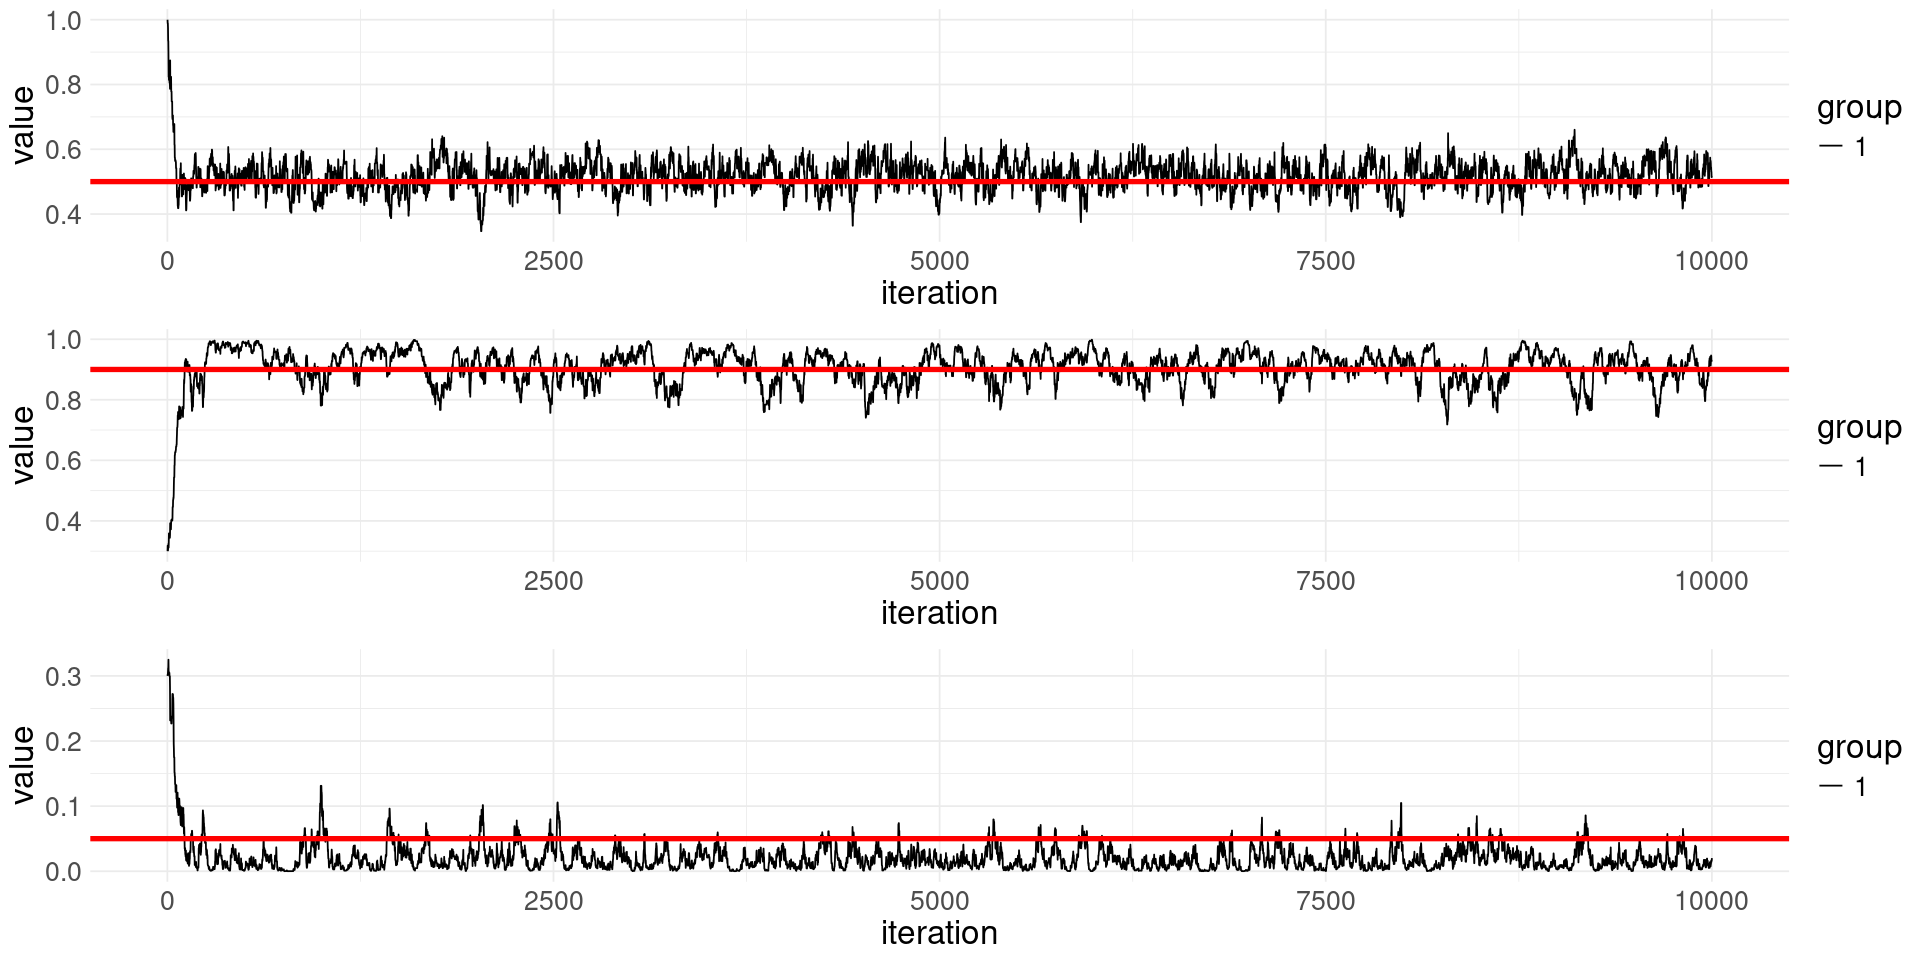

In [10]:
set.seed(10)

yh <- sample_garch(1000, alpha = c(0.5, 0.9), beta = c(0.05))
y <- yh$y
h <- yh$h

alpha0 <- c(1.0, 0.3)
beta0 <- c(0.3)
start <- Sys.time()
fit <- sample_posterior_garch_dirichlet_cpp(y, 10000, alpha0 = alpha0, beta0 = beta0, tau = 500, sigma_alpha0 = 0.05)
Sys.time() - start

# Direct acceptances
sum(fit$log_acceptance_probs > 0)

trace_alpha0 <- trace_plots(list(fit$alpha[,1])) + geom_hline(aes(yintercept = 0.5), color = "red", linewidth = 1.5)
trace_alpha1 <- trace_plots(list(fit$alpha[,2])) + geom_hline(aes(yintercept = 0.9), color = "red", linewidth = 1.5)
trace_beta <- trace_plots(list(fit$beta)) + geom_hline(aes(yintercept = 0.05), color = "red", linewidth = 1.5)

options(repr.plot.width = 16, repr.plot.height = 8)
plot_grid( trace_alpha0, trace_alpha1, trace_beta, nrow = 3)

Time difference of 23.51087 secs

[1] 2983

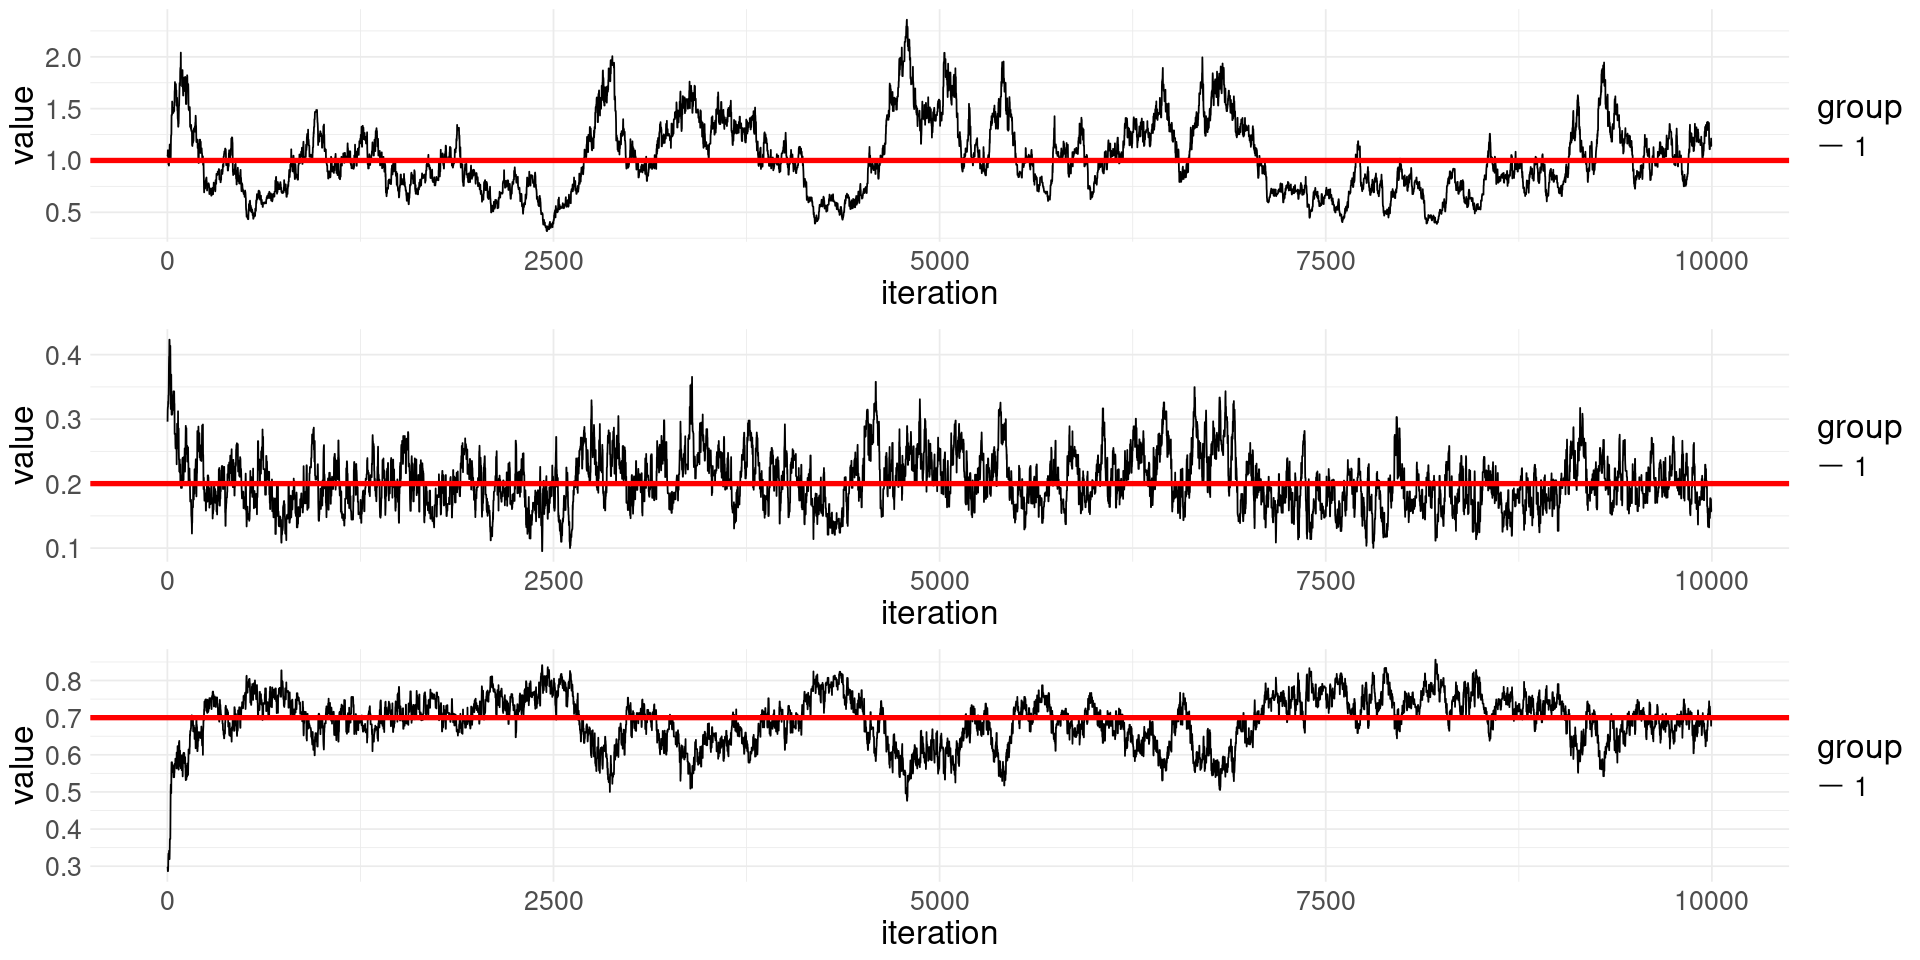

In [11]:
set.seed(10)

alpha <- c(1, 0.2)
beta <- c(0.7)
yh <- sample_garch(1000, alpha = alpha, beta = beta)
y <- yh$y
h <- yh$h

alpha0 <- c(1.0, 0.3)
beta0 <- c(0.3)
start <- Sys.time()
fit <- sample_posterior_garch_dirichlet_cpp(y, 10000, alpha0 = alpha0, beta0 = beta0, tau = 500, sigma_alpha0 = 0.05)
Sys.time() - start

# Direct acceptances
sum(fit$log_acceptance_probs > 0)

trace_alpha0 <- trace_plots(list(fit$alpha[,1])) + geom_hline(aes(yintercept = 1), color = "red", linewidth = 1.5)
trace_alpha1 <- trace_plots(list(fit$alpha[,2])) + geom_hline(aes(yintercept = alpha[2]), color = "red", linewidth = 1.5)
trace_beta <- trace_plots(list(fit$beta)) + geom_hline(aes(yintercept = beta), color = "red", linewidth = 1.5)

options(repr.plot.width = 16, repr.plot.height = 8)
plot_grid( trace_alpha0, trace_alpha1, trace_beta, nrow = 3)

### GARCH(2,1)

[1] 0.28840983 0.07111757 0.00010000 0.89870937

Time difference of 23.02348 secs

[1] 2403

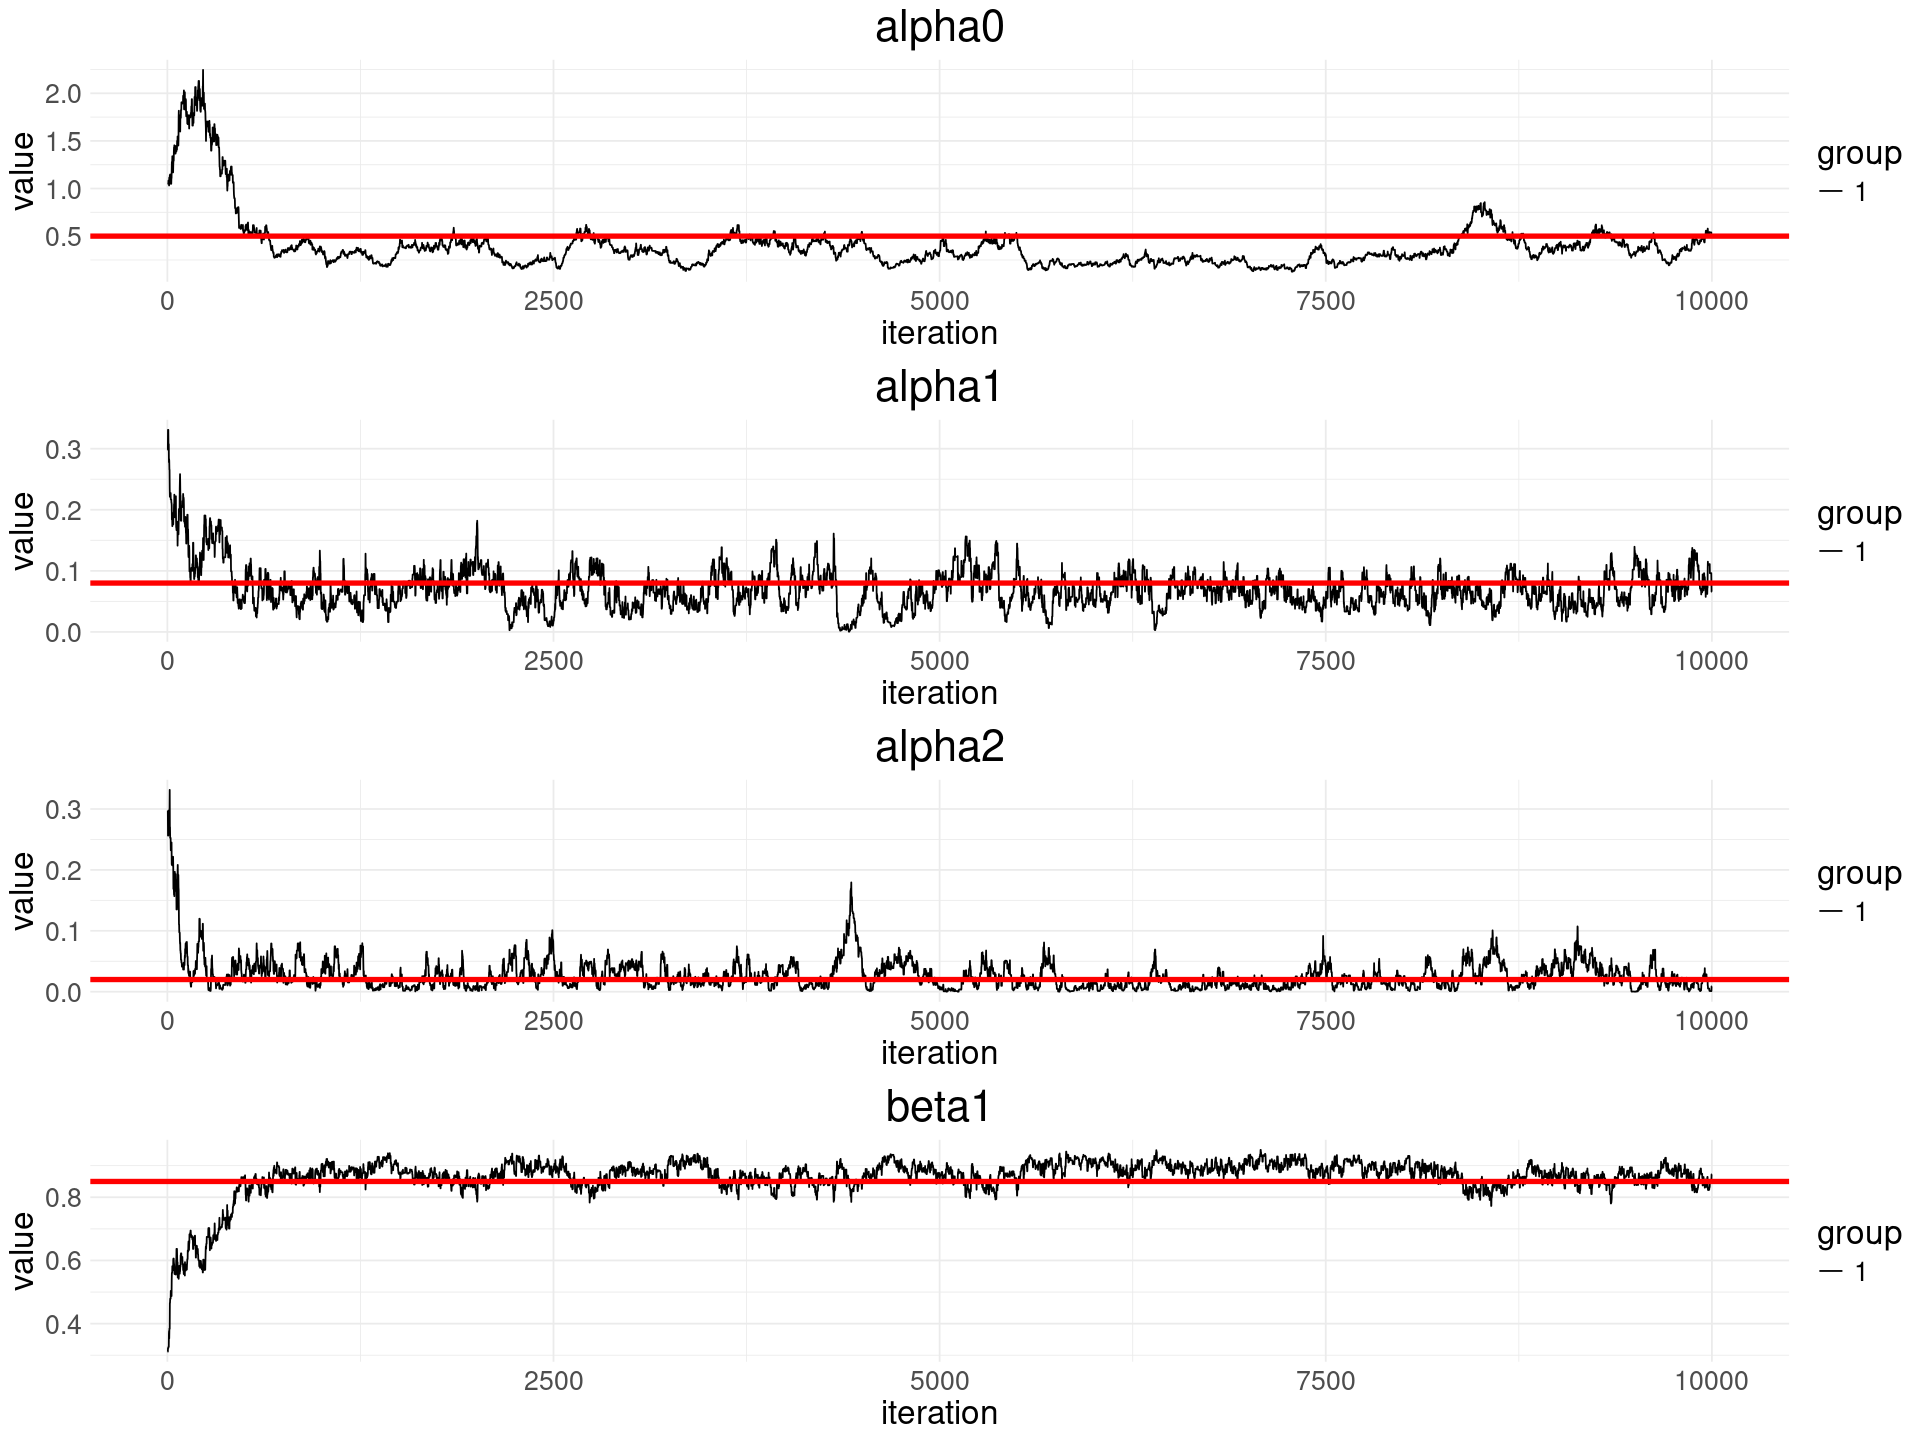

In [7]:
set.seed(10)

yh <- sample_garch(1000, alpha = c(0.5, 0.08, 0.02), beta = 0.85)
y <- yh$y
h <- yh$h

emv_estimate <- garch_emv(y, c(1.0, 0.3, 0.3), c(0.3))
emv_estimate$par

# theta0 <- c(1.0, 0.3, 0.3)
# theta0 <- emv_y_problematic$par
start <- Sys.time()
fit <- sample_posterior_garch_dirichlet_cpp(y, 10000, c(1.0, 0.3, 0.3), c(0.3), 500, 0.05)
Sys.time() - start

sum(fit$log_acceptance_probs > 0)

trace_alpha0 <- trace_plots(list(fit$alpha[,1])) + geom_hline(aes(yintercept = 0.5), color = "red", linewidth = 1.5) + labs(title = "alpha0")
trace_alpha1 <- trace_plots(list(fit$alpha[,2])) + geom_hline(aes(yintercept = 0.08), color = "red", linewidth = 1.5) + labs(title = "alpha1")
trace_alpha2 <- trace_plots(list(fit$alpha[,3])) + geom_hline(aes(yintercept = 0.02), color = "red", linewidth = 1.5) + labs(title = "alpha2")
trace_beta <- trace_plots(list(fit$beta)) + geom_hline(aes(yintercept = 0.85), color = "red", linewidth = 1.5) + labs(title = "beta1")

options(repr.plot.width = 16, repr.plot.height = 12)
plot_grid( trace_alpha0, trace_alpha1, trace_alpha2, trace_beta, nrow = 4)

As it can be seen, the MH proposal with the Dirichlet innovations seems to extend pretty well to different orders of GARCH(p,q) and also provide great stability for the posterior distribution samples. We may proceed now obtaining the desired distributions for the maximum values of the divergence metrics in each scenario. We will start by rerunning all scenarios in a grid for the GARCH(1,1) model.

Afterwards, following the recommendation of Reviwer 2, we perform simulations for GARCH(2,1) and GARCH(1,2) models in order to properly show the generality of our methodology, apart from its tedious process of having to establish grids and simulations for the diagnostics calibrations.

### Single test with GARCH(1,1)

In [8]:
T <- 1000
niter <- 10000
burnin <- 5000
alpha <- c(0.1, 0.1)
beta <- c(0.85)

# -------------------------------- Sample from the GARCH model --------------------------------
yh <- sample_garch(T, alpha = alpha, beta = beta)
y <- yh$y
h <- yh$h

# -------------------------------- Fit the Bayesian model --------------------------------
main_start <- Sys.time()
fit_obj <- sample_posterior_garch_dirichlet_cpp(y, 10000, c(1.0, 0.3), c(0.3), 500, 0.05)
sampling_time <- Sys.time() - start

# -------------------------------- Process posterior sample --------------------------------
final_alpha <- fit_obj$alpha[ (burnin+1):niter, ]
final_beta <- fit_obj$beta[ (burnin+1):niter, ]
final_hs <- fit_obj$h[(burnin+1):niter,]

summ_colnames <- c("mean", "median", "sd", "2.5%", "25%", "50%", "75%", "97.5%")
summ_rownames <- c("alpha0", "alpha1", "beta")
summ <- data.frame(
    c(mean(final_alpha[,1]), mean(final_alpha[,2]), mean(final_beta)),
    c(median(final_alpha[,1]), median(final_alpha[,2]), median(final_beta)),
    c(sd(final_alpha[,1]), sd(final_alpha[,2]), sd(final_beta)),
    c(quantile(final_alpha[,1], 0.025), quantile(final_alpha[,2], 0.025), quantile(final_beta, 0.025)),
    c(quantile(final_alpha[,1], 0.25), quantile(final_alpha[,2], 0.25), quantile(final_beta, 0.25)),
    c(quantile(final_alpha[,1], 0.5), quantile(final_alpha[,2], 0.5), quantile(final_beta, 0.5)),
    c(quantile(final_alpha[,1], 0.75), quantile(final_alpha[,2], 0.75), quantile(final_beta, 0.75)),
    c(quantile(final_alpha[,1], 0.975), quantile(final_alpha[,2], 0.975), quantile(final_beta, 0.975))
)
colnames(summ) <- summ_colnames
rownames(summ) <- summ_rownames

# -------------------------------- Extract parameters --------------------------------
# alpha0, alpha1, beta1
thetas <- cbind(final_alpha[,1], final_alpha[,2], final_beta)

hs <- final_hs
colnames(thetas) <- c("alpha0", "alpha1", "beta")

# summaries[[i]] <- fit_obj$summary

# -------------------------------- Obtain the divergences --------------------------------
start <- Sys.time()
div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
divergence_time <- Sys.time() - start

print(paste0("Sampling time:", sampling_time))
print(paste0("Divergence time:", divergence_time))

[1] "Sampling time:45.0909969806671"
[1] "Divergence time:14.2069807052612"


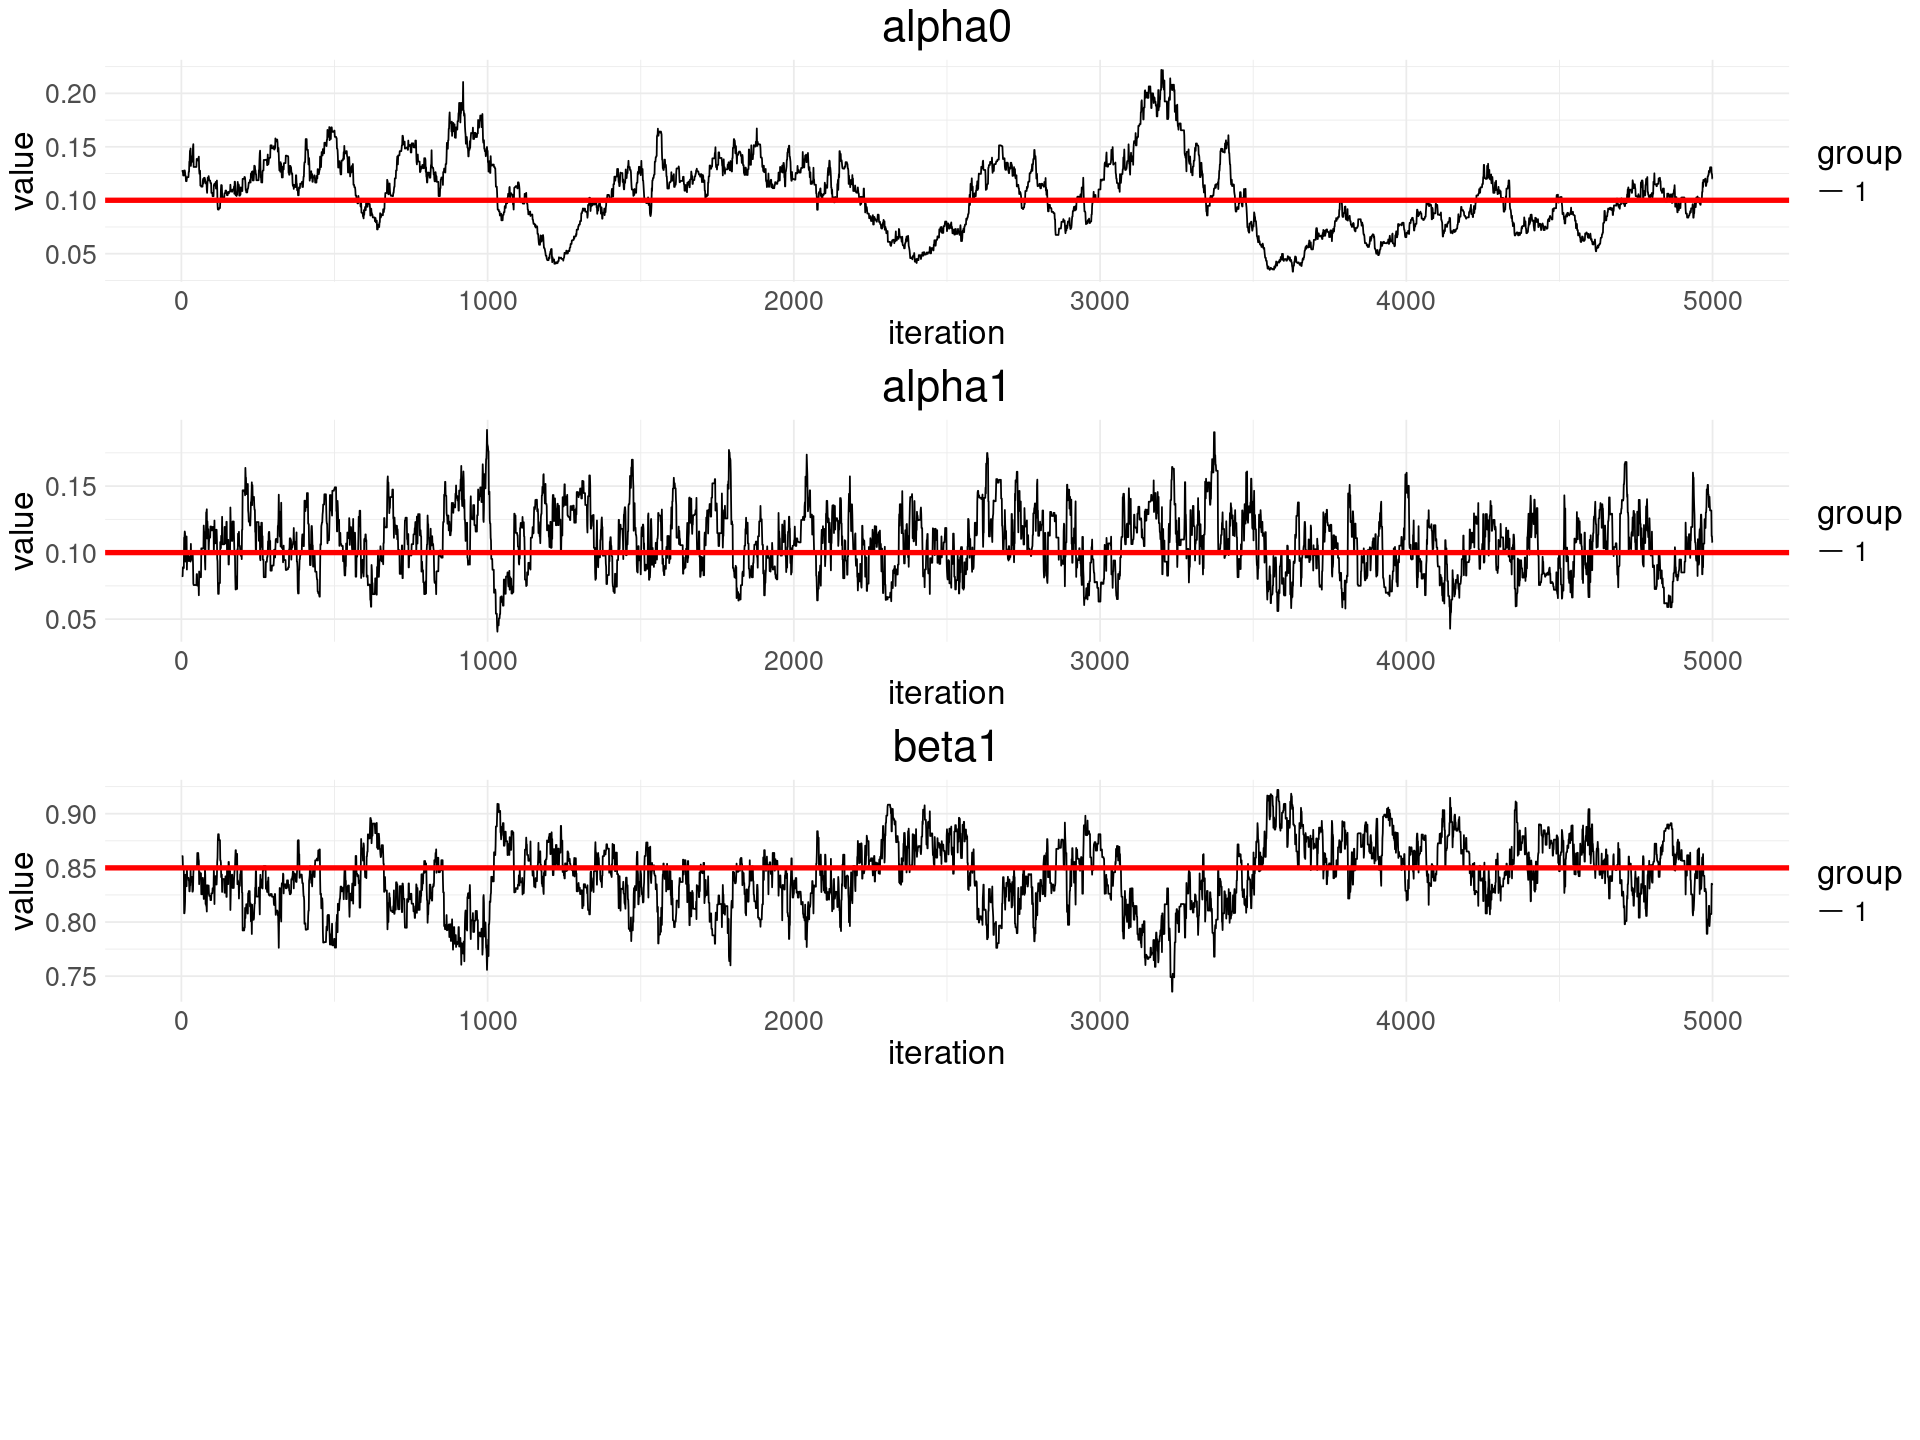

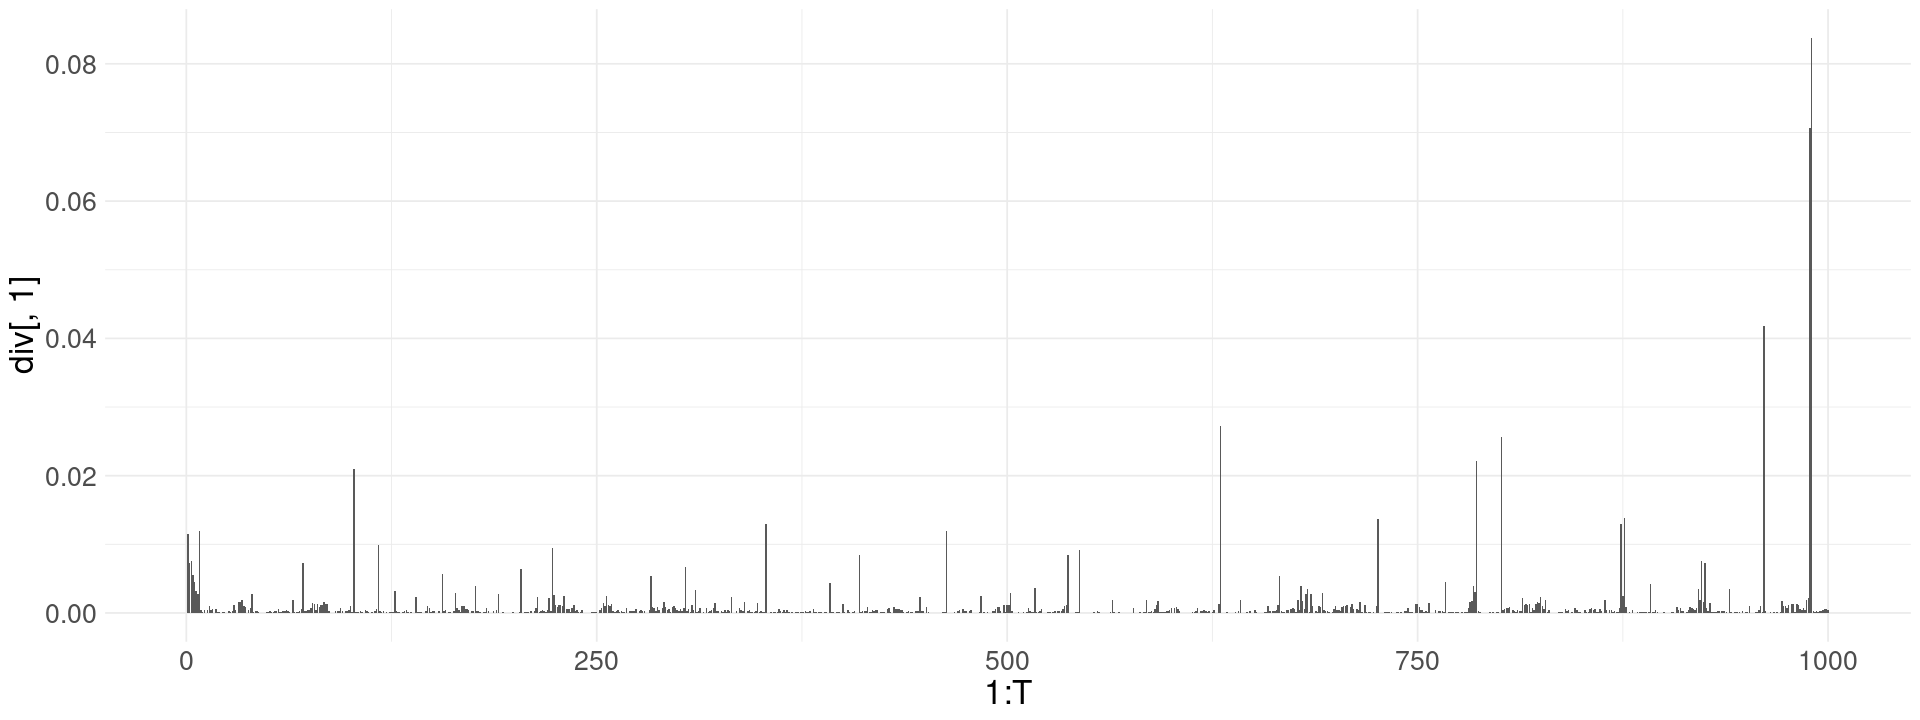

In [9]:
trace_alpha0 <- trace_plots(list(final_alpha[,1])) + geom_hline(aes(yintercept = 0.1), color = "red", linewidth = 1.5) + labs(title = "alpha0")
trace_alpha1 <- trace_plots(list(final_alpha[,2])) + geom_hline(aes(yintercept = 0.1), color = "red", linewidth = 1.5) + labs(title = "alpha1")
trace_beta <- trace_plots(list(final_beta)) + geom_hline(aes(yintercept = 0.85), color = "red", linewidth = 1.5) + labs(title = "beta1")

options(repr.plot.width = 16, repr.plot.height = 12)
plot_grid( trace_alpha0, trace_alpha1, trace_beta, nrow = 4)

options(repr.plot.width = 16, repr.plot.height = 6)
ggplot()+
    geom_col(aes(x = 1:T, y = div[,1]))

Everything seems to be working the way we expected and according to our previous results. However, now we can count on a very robust MH algorithm to obtain our posteriors. Therefore, we do not need to worry about explosive behaviour in any of our simulation examples. That approach will also be very valuable for the implementation of higher order GARCH models.

### Single test with GARCH(2,1)

In [ ]:
T <- 1000
niter <- 10000
burnin <- 5000
alpha <- c(0.5, 0.08, 0.02)
beta <- c(0.85)

# -------------------------------- Sample from the GARCH model --------------------------------
yh <- sample_garch(T, alpha = alpha, beta = beta)
y <- yh$y
h <- yh$h

# -------------------------------- Fit the Bayesian model --------------------------------
main_start <- Sys.time()
fit_obj <- sample_posterior_garch_dirichlet_cpp(y, 10000, c(1.0, 0.3, 0.3), c(0.3), 500, 0.05)
sampling_time <- Sys.time() - start

# -------------------------------- Process posterior sample --------------------------------
final_alpha <- fit_obj$alpha[ (burnin+1):niter, ]
final_beta <- fit_obj$beta[ (burnin+1):niter, ]
final_hs <- fit_obj$h[(burnin+1):niter,]

summ_colnames <- c("mean", "median", "sd", "2.5%", "25%", "50%", "75%", "97.5%")
summ_rownames <- c("alpha0", "alpha1", "alpha2", "beta")
summ <- data.frame(
    c(mean(final_alpha[,1]), mean(final_alpha[,2]), mean(final_alpha[,3]), mean(final_beta)),
    c(median(final_alpha[,1]), median(final_alpha[,2]), median(final_alpha[,3]), median(final_beta)),
    c(sd(final_alpha[,1]), sd(final_alpha[,2]), sd(final_alpha[,3]), sd(final_beta)),
    c(quantile(final_alpha[,1], 0.025), quantile(final_alpha[,2], 0.025), quantile(final_alpha[,3], 0.025), quantile(final_beta, 0.025)),
    c(quantile(final_alpha[,1], 0.25), quantile(final_alpha[,2], 0.25), quantile(final_alpha[,3], 0.25), quantile(final_beta, 0.25)),
    c(quantile(final_alpha[,1], 0.5), quantile(final_alpha[,2], 0.5), quantile(final_alpha[,3], 0.5), quantile(final_beta, 0.5)),
    c(quantile(final_alpha[,1], 0.75), quantile(final_alpha[,2], 0.75), quantile(final_alpha[,3], 0.75), quantile(final_beta, 0.75)),
    c(quantile(final_alpha[,1], 0.975), quantile(final_alpha[,2], 0.975), quantile(final_alpha[,3], 0.975), quantile(final_beta, 0.975))
)
colnames(summ) <- summ_colnames
rownames(summ) <- summ_rownames

# -------------------------------- Extract parameters --------------------------------
# alpha0, alpha1, beta1
thetas <- cbind(final_alpha[,1], final_alpha[,2], final_alpha[,3], final_beta)

hs <- final_hs
colnames(thetas) <- c("alpha0", "alpha1", "alpha2", "beta")

# summaries[[i]] <- fit_obj$summary

# -------------------------------- Obtain the divergences --------------------------------
start <- Sys.time()
div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 2, q = 1, k_values = 1:T, verbose = FALSE)
divergence_time <- Sys.time() - start

print(paste0("Sampling time:", sampling_time))
print(paste0("Divergence time:", divergence_time))

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 6)
ggplot()+
    geom_col(aes(x = 1:T, y = div[,1]))

In [ ]:
garch11_div_sim <- function(nsim, T, alpha, beta, disturbed = NULL, L = 5, niter = 10000, burnin = 5000, seed = 42){
    # -------------------------------- Save the current random state before sampling --------------------------------
    # current_random_state <- .Random.seed
    set.seed(seed)
    
    divergences <- list()
    summaries <- list()
    ys <- list()
    sampling_times <- c()
    divergence_times <- c()
    total_times <- c()
    
    pb <- progressBar(min = 0, max = nsim)
    for(i in 1:nsim){
        # -------------------------------- Sample from the GARCH model --------------------------------
        yh <- sample_garch(T, alpha = alpha, beta = beta)
        y <- yh$y
        h <- yh$h
        
        # -------------------------------- Disturb all indexes required --------------------------------
        for(j in disturbed){
            y[j] <- y[j] + L*sqrt(h[j])*sign(y[j])
        }
        
        # -------------------------------- Fit the Bayesian model --------------------------------
        main_start <- Sys.time()
        # fit_obj <- fit_garch_ardia(y, niter = niter, burnin = burnin, seed = seed+1, emv_guess = c(alpha0, alpha1, beta))
        fit_obj <- sample_posterior_garch_dirichlet_cpp(y, 10000, c(1.0, 0.3), c(0.3), 500, 0.05)
        sampling_time <- Sys.time() - start

        # -------------------------------- Process posterior sample --------------------------------
        final_alpha <- fit_obj$alpha[ (burnin+1):niter, ]
        final_beta <- fit_obj$beta[ (burnin+1):niter, ]
        final_hs <- fit_obj$h[(burnin+1):niter,]
        
        summ_colnames <- c("mean", "median", "sd", "2.5%", "25%", "50%", "75%", "97.5%")
        summ_rownames <- c("alpha0", "alpha1", "beta")
        summ <- data.frame(
            c(mean(final_alpha[,1]), mean(final_alpha[,2]), mean(final_beta)),
            c(median(final_alpha[,1]), median(final_alpha[,2]), median(final_beta)),
            c(sd(final_alpha[,1]), sd(final_alpha[,2]), sd(final_beta)),
            c(quantile(final_alpha[,1], 0.025), quantile(final_alpha[,2], 0.025), quantile(final_beta, 0.025)),
            c(quantile(final_alpha[,1], 0.25), quantile(final_alpha[,2], 0.25), quantile(final_beta, 0.25)),
            c(quantile(final_alpha[,1], 0.5), quantile(final_alpha[,2], 0.5), quantile(final_beta, 0.5)),
            c(quantile(final_alpha[,1], 0.75), quantile(final_alpha[,2], 0.75), quantile(final_beta, 0.75)),
            c(quantile(final_alpha[,1], 0.975), quantile(final_alpha[,2], 0.975), quantile(final_beta, 0.975))
        )
        colnames(summ) <- summ_colnames
        rownames(summ) <- summ_rownames
        
        # -------------------------------- Extract parameters --------------------------------
        # alpha0, alpha1, beta1
        thetas <- cbind(final_alpha[,1], final_alpha[,2], final_beta)
        
        hs <- final_hs
        colnames(thetas) <- c("alpha0", "alpha1", "beta")
        
        summaries[[i]] <- summ
        
        # -------------------------------- Obtain the divergences --------------------------------
        start <- Sys.time()
        div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
        divergence_time <- Sys.time() - start
        
        total_time <- Sys.time() - main_start
        
        # -------------------------------- Save the relevant values --------------------------------
        sampling_times[i] <- sampling_time
        divergence_times[i] <- divergence_time
        total_times[i] <- total_time
        colnames(div) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
        divergences[[i]] <- div
        ys[[i]] <- y
        
        # Invoke the Garbage collector for memory maintenance
        invisible(gc())
        setTxtProgressBar(pb, i)
    }
    close(pb)
    
    # return to the environment to the previous random state
    # .Random.seed <- current_random_state
    
    return(list(
        "ys" = ys,
        "divergences" = divergences,
        "summaries" = summaries,
        "sampling_times" = sampling_times,
        "divergence_times" = divergence_times,
        "total_times" = total_times,
        "pars" = c(alpha, beta)
    ))
}

# Single test GARCH(1,2) model

In [ ]:
T <- 1000
niter <- 10000
burnin <- 5000
alpha <- c(0.5, 0.05)
beta <- c(0.05, 0.05)

# -------------------------------- Sample from the GARCH model --------------------------------
yh <- sample_garch(T, alpha = alpha, beta = beta)
y <- yh$y
h <- yh$h

set.seed(10)

# -------------------------------- Fit the Bayesian model --------------------------------
main_start <- Sys.time()
fit_obj <- sample_posterior_garch_dirichlet_cpp(y, 10000, c(1.0, 0.3), c(0.3, 0.3), 500, 0.05)
sampling_time <- Sys.time() - start

# -------------------------------- Process posterior sample --------------------------------
final_alpha <- fit_obj$alpha[ (burnin+1):niter, ]
final_beta <- fit_obj$beta[ (burnin+1):niter, ]
final_hs <- fit_obj$h[(burnin+1):niter,]

summ_colnames <- c("mean", "median", "sd", "2.5%", "25%", "50%", "75%", "97.5%")
summ_rownames <- c("alpha0", "alpha1", "beta1", "beta2")
summ <- data.frame(
    c(mean(final_alpha[,1]), mean(final_alpha[,2]), mean(final_beta[,1]), mean(final_beta[,1])),
    c(median(final_alpha[,1]), median(final_alpha[,2]), median(final_beta[,1]), median(final_beta[,1])),
    c(sd(final_alpha[,1]), sd(final_alpha[,2]), sd(final_beta[,1]), sd(final_beta[,1])),
    c(quantile(final_alpha[,1], 0.025), quantile(final_alpha[,2], 0.025), quantile(final_beta[,1], 0.025), quantile(final_beta[,1], 0.025)),
    c(quantile(final_alpha[,1], 0.25), quantile(final_alpha[,2], 0.25), quantile(final_beta[,1], 0.25), quantile(final_beta[,1], 0.25)),
    c(quantile(final_alpha[,1], 0.5), quantile(final_alpha[,2], 0.5), quantile(final_beta[,1], 0.5), quantile(final_beta[,1], 0.5)),
    c(quantile(final_alpha[,1], 0.75), quantile(final_alpha[,2], 0.75), quantile(final_beta[,1], 0.75), quantile(final_beta[,1], 0.75)),
    c(quantile(final_alpha[,1], 0.975), quantile(final_alpha[,2], 0.975), quantile(final_beta[,1], 0.975), quantile(final_beta[,1], 0.975))
)
colnames(summ) <- summ_colnames
rownames(summ) <- summ_rownames

# -------------------------------- Extract parameters --------------------------------
# alpha0, alpha1, beta1
thetas <- cbind(final_alpha[,1], final_alpha[,2], final_beta[,1], final_beta[,2])

hs <- final_hs
colnames(thetas) <- c("alpha0", "alpha1", "beta1", "beta2")

# summaries[[i]] <- fit_obj$summary

# -------------------------------- Obtain the divergences --------------------------------
start <- Sys.time()
div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 1, q = 2, k_values = 1:T, verbose = FALSE)
divergence_time <- Sys.time() - start

print(paste0("Sampling time:", sampling_time))
print(paste0("Divergence time:", divergence_time))

In [ ]:
trace_alpha0 <- histplots_plots(list(final_alpha[,1])) + geom_vline(aes(xintercept = 0.5), color = "red", linewidth = 1.5) + labs(title = "alpha0")
trace_alpha1 <- histplots_plots(list(final_alpha[,2])) + geom_vline(aes(xintercept = 0.05), color = "red", linewidth = 1.5) + labs(title = "alpha1")
trace_beta1 <- histplots_plots(list(final_beta[,1])) + geom_vline(aes(xintercept = 0.05), color = "red", linewidth = 1.5) + labs(title = "beta1")
trace_beta2 <- histplots_plots(list(final_beta[,2])) + geom_vline(aes(xintercept = 0.05), color = "red", linewidth = 1.5) + labs(title = "beta2")

options(repr.plot.width = 16, repr.plot.height = 12)
plot_grid( trace_alpha0, trace_alpha1, trace_beta1, trace_beta2, nrow = 4)

In [ ]:
trace_alpha0 <- trace_plots(list(final_alpha[,1])) + geom_hline(aes(yintercept = 0.5), color = "red", linewidth = 1.5) + labs(title = "alpha0")
trace_alpha1 <- trace_plots(list(final_alpha[,2])) + geom_hline(aes(yintercept = 0.05), color = "red", linewidth = 1.5) + labs(title = "alpha1")
trace_beta1 <- trace_plots(list(final_beta[,1])) + geom_hline(aes(yintercept = 0.05), color = "red", linewidth = 1.5) + labs(title = "beta1")
trace_beta2 <- trace_plots(list(final_beta[,2])) + geom_hline(aes(yintercept = 0.05), color = "red", linewidth = 1.5) + labs(title = "beta2")

options(repr.plot.width = 16, repr.plot.height = 12)
plot_grid( trace_alpha0, trace_alpha1, trace_beta1, trace_beta2, nrow = 4)

options(repr.plot.width = 16, repr.plot.height = 6)
ggplot()+
    geom_col(aes(x = 1:T, y = div[,1]))

# Simulations

In [ ]:
nsim <- 250
niter <- 10000
burnin <- 5000
seed = 10

## Scenario 1 - $\alpha_0 = 0.1$

* 1.1: $\alpha_1 = 0.1$, $\beta_1 = 0.85$ - Sum: 0.95
* 1.2: $\alpha_1 = 0.1$, $\beta_1 = 0.6$ - Sum: 0.7
* 1.3: $\alpha_1 = 0.1$, $\beta_1 = 0.35$ - Sum: 0.45
* 1.4: $\alpha_1 = 0.1$, $\beta_1 = 0.1$ - Sum: 0.2
* 1.5: $\alpha_1 = 0.35$, $\beta_1 = 0.6$ - Sum: 0.95
* 1.6: $\alpha_1 = 0.35$, $\beta_1 = 0.35$ - Sum: 0.7
* 1.7: $\alpha_1 = 0.35$, $\beta_1 = 0.1$ - Sum: 0.45
* 1.8: $\alpha_1 = 0.6$, $\beta_1 = 0.35$ - Sum: 0.95
* 1.9: $\alpha_1 = 0.6$, $\beta_1 = 0.1$ - Sum: 0.7
* 1.10: $\alpha_1 = 0.85$, $\beta_1 = 0.1$ - Sum: 0.95

### Scenario 1.1 - $\alpha_0 = 0.1$, $\alpha_1 = 0.1$, $\beta_1 = 0.85$

In [17]:
sim1.1_1000 <- garch11_div_sim(nsim = 250, T = 1000, alpha = c(0.1, 0.1), beta = c(0.85), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.1_1000", file = "Simulations2/sim1.1.RData")

  |====================================================| 100%, Elapsed 02:41:28


### Scenario 1.2 - $\alpha_0 = 0.1$, $\alpha_1 = 0.1$, $\beta_1 = 0.6$

In [18]:
sim1.2_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.1), beta = c(0.6), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.2_1000", file = "Simulations2/sim1.2.RData")

  |====================================================| 100%, Elapsed 02:41:45


### Scenario 1.3 - $\alpha_0 = 0.1$, $\alpha_1 = 0.1$, $\beta_1 = 0.35$

In [ ]:
sim1.3_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.1), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.3_1000", file = "Simulations2/sim1.3.RData")

  |                                                              |   0%, ETA NA

### Scenario 1.4 - $\alpha_0 = 0.1$, $\alpha_1 = 0.1$, $\beta_1 = 0.1$

In [14]:
sim1.4_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.1), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.4_1000", file = "Simulations2/sim1.4.RData")

  |====================================================| 100%, Elapsed 02:26:45


### Scenario 1.5 - $\alpha_0 = 0.1$, $\alpha_1 = 0.35$, $\beta_1 = 0.6$

In [15]:
sim1.5_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.35), beta = c(0.6), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.5_1000", file = "Simulations2/sim1.5.RData")

  |====================================================| 100%, Elapsed 02:27:57


### Scenario 1.6 - $\alpha_0 = 0.1$, $\alpha_1 = 0.35$, $\beta_1 = 0.35$

In [16]:
sim1.6_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.35), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.6_1000", file = "Simulations2/sim1.6.RData")

  |====================================================| 100%, Elapsed 02:27:14


### Scenario 1.7 - $\alpha_0 = 0.1$, $\alpha_1 = 0.35$, $\beta_1 = 0.1$

In [17]:
sim1.7_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.35), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.7_1000", file = "Simulations2/sim1.7.RData")

  |====================================================| 100%, Elapsed 02:26:32


### Scenario 1.8 - $\alpha_0 = 0.1$, $\alpha_1 = 0.6$, $\beta_1 = 0.35$

In [18]:
sim1.8_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.6), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.8_1000", file = "Simulations2/sim1.8.RData")

  |====================================================| 100%, Elapsed 02:28:45


### Scenario 1.9 - $\alpha_0 = 0.1$, $\alpha_1 = 0.6$, $\beta_1 = 0.1$

In [19]:
sim1.9_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.6), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim1.9_1000", file = "Simulations2/sim1.9.RData")

  |====================================================| 100%, Elapsed 02:27:33


### Scenario 1.10 - $\alpha_0 = 0.1$, $\alpha_1 = 0.85$, $\beta_1 = 0.1$

In [20]:
sim1.10_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(0.1, 0.85), beta = c(0.1), disturbed = NULL, L = 5,
                                niter = 10000, burnin = 5000, seed = 10)
save("sim1.10_1000", file = "Simulations2/sim1.10.RData")

  |====================================================| 100%, Elapsed 02:28:00


### Scenario 2.1 - $\alpha_0 = 1$, $\alpha_1 = 0.1$, $\beta_1 = 0.85$

In [21]:
sim2.1_1000 <- garch11_div_sim(nsim = 250, T = 1000, alpha = c(1.0, 0.1), beta = c(0.85), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.1_1000", file = "Simulations2/sim2.1.RData")

  |====================================================| 100%, Elapsed 02:25:13


### Scenario 2.2 - $\alpha_0 = 1$, $\alpha_1 = 0.1$, $\beta_1 = 0.6$

In [22]:
sim2.2_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.1), beta = c(0.6), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.2_1000", file = "Simulations2/sim2.2.RData")

  |====================================================| 100%, Elapsed 02:25:51


### Scenario 2.3 - $\alpha_0 = 1$, $\alpha_1 = 0.1$, $\beta_1 = 0.35$

In [23]:
sim2.3_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.1), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.3_1000", file = "Simulations2/sim2.3.RData")

  |====================================================| 100%, Elapsed 02:25:59


### Scenario 2.4 - $\alpha_0 = 1$, $\alpha_1 = 0.1$, $\beta_1 = 0.1$

In [24]:
sim2.4_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.1), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.4_1000", file = "Simulations2/sim2.4.RData")

  |====================================================| 100%, Elapsed 02:23:17


### Scenario 2.5 - $\alpha_0 = 1$, $\alpha_1 = 0.35$, $\beta_1 = 0.6$

In [25]:
sim2.5_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.35), beta = c(0.6), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.5_1000", file = "Simulations2/sim2.5.RData")

  |====================================================| 100%, Elapsed 02:27:36


### Scenario 2.6 - $\alpha_0 = 1$, $\alpha_1 = 0.35$, $\beta_1 = 0.35$

In [26]:
sim2.6_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.35), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.6_1000", file = "Simulations2/sim2.6.RData")

  |====================================================| 100%, Elapsed 02:27:19


### Scenario 2.7 - $\alpha_0 = 1$, $\alpha_1 = 0.35$, $\beta_1 = 0.1$

In [27]:
sim2.7_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.35), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.7_1000", file = "Simulations2/sim2.7.RData")

  |====================================================| 100%, Elapsed 02:25:25


### Scenario 2.8 - $\alpha_0 = 1$, $\alpha_1 = 0.6$, $\beta_1 = 0.35$

In [28]:
sim2.8_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.6), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.8_1000", file = "Simulations2/sim2.8.RData")

  |                                                              |   0%, ETA NA

### Scenario 2.9 - $\alpha_0 = 1$, $\alpha_1 = 0.6$, $\beta_1 = 0.1$

In [ ]:
sim2.9_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.6), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim2.9_1000", file = "Simulations2/sim2.9.RData")

### Scenario 2.10 - $\alpha_0 = 1$, $\alpha_1 = 0.85$, $\beta_1 = 0.1$

In [ ]:
sim2.10_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.85), beta = c(0.1), disturbed = NULL, L = 5,
                                niter = 10000, burnin = 5000, seed = 10)
save("sim2.10_1000", file = "Simulations2/sim2.10.RData")

### Scenario 3.1 - $\alpha_0 = 2$, $\alpha_1 = 0.1$, $\beta_1 = 0.85$

In [ ]:
sim3.1_1000 <- garch11_div_sim(nsim = 250, T = 1000, alpha = c(2.0, 0.1), beta = c(0.85), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.1_1000", file = "Simulations2/sim3.1.RData")

  |=                                                       |   1%, ETA 01:38:55

### Scenario 3.2 - $\alpha_0 = 2$, $\alpha_1 = 0.1$, $\beta_1 = 0.6$

In [ ]:
sim3.2_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.1), beta = c(0.6), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.2_1000", file = "Simulations2/sim3.2.RData")

### Scenario 3.3 - $\alpha_0 = 2$, $\alpha_1 = 0.1$, $\beta_1 = 0.35$

In [ ]:
sim3.3_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.1), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.3_1000", file = "Simulations2/sim3.3.RData")

### Scenario 3.4 - $\alpha_0 = 2$, $\alpha_1 = 0.1$, $\beta_1 = 0.1$

In [ ]:
sim3.4_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.1), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.4_1000", file = "Simulations2/sim3.4.RData")

### Scenario 3.5 - $\alpha_0 = 2$, $\alpha_1 = 0.35$, $\beta_1 = 0.6$

In [ ]:
sim3.5_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.35), beta = c(0.6), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.5_1000", file = "Simulations2/sim3.5.RData")

### Scenario 3.6 - $\alpha_0 = 2$, $\alpha_1 = 0.35$, $\beta_1 = 0.35$

In [ ]:
sim3.6_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.35), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.6_1000", file = "Simulations2/sim3.6.RData")

  |                                                        |   1%, ETA 01:21:12

### Scenario 3.7 - $\alpha_0 = 2$, $\alpha_1 = 0.35$, $\beta_1 = 0.1$

In [17]:
sim3.7_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.35), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.7_1000", file = "Simulations2/sim3.7.RData")

  |====================================================| 100%, Elapsed 02:42:08


### Scenario 3.8 - $\alpha_0 = 2$, $\alpha_1 = 0.6$, $\beta_1 = 0.35$

In [16]:
sim3.8_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.6), beta = c(0.35), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.8_1000", file = "Simulations2/sim3.8.RData")

  |====================================================| 100%, Elapsed 02:43:01


### Scenario 3.9 - $\alpha_0 = 2$, $\alpha_1 = 0.6$, $\beta_1 = 0.1$

In [15]:
sim3.9_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.6), beta = c(0.1), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim3.9_1000", file = "Simulations2/sim3.9.RData")

  |====================================================| 100%, Elapsed 02:42:53


### Scenario 3.10 - $\alpha_0 = 2$, $\alpha_1 = 0.85$, $\beta_1 = 0.1$

In [14]:
sim3.10_1000 <- garch11_div_sim(nsim = nsim, T = 1000, alpha = c(2.0, 0.85), beta = c(0.1), disturbed = NULL, L = 5,
                                niter = 10000, burnin = 5000, seed = 10)
save("sim3.10_1000", file = "Simulations2/sim3.10.RData")

  |====================================================| 100%, Elapsed 02:43:13


In [88]:
sim3.10_1000$summaries[[5]]

,mean,median,sd,2.5%,25%,50%,75%,97.5%
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
alpha0,2.1386368,2.1434623,0.21529530,1.71032386,1.99842259,2.1434623,2.2791336,2.5747256
alpha1,0.8268549,0.8300444,0.04723865,0.72519323,0.79570014,0.8300444,0.8624688,0.9065284
beta,0.1171826,0.1158209,0.02977427,0.06457229,0.09602011,0.1158209,0.1366407,0.1830365


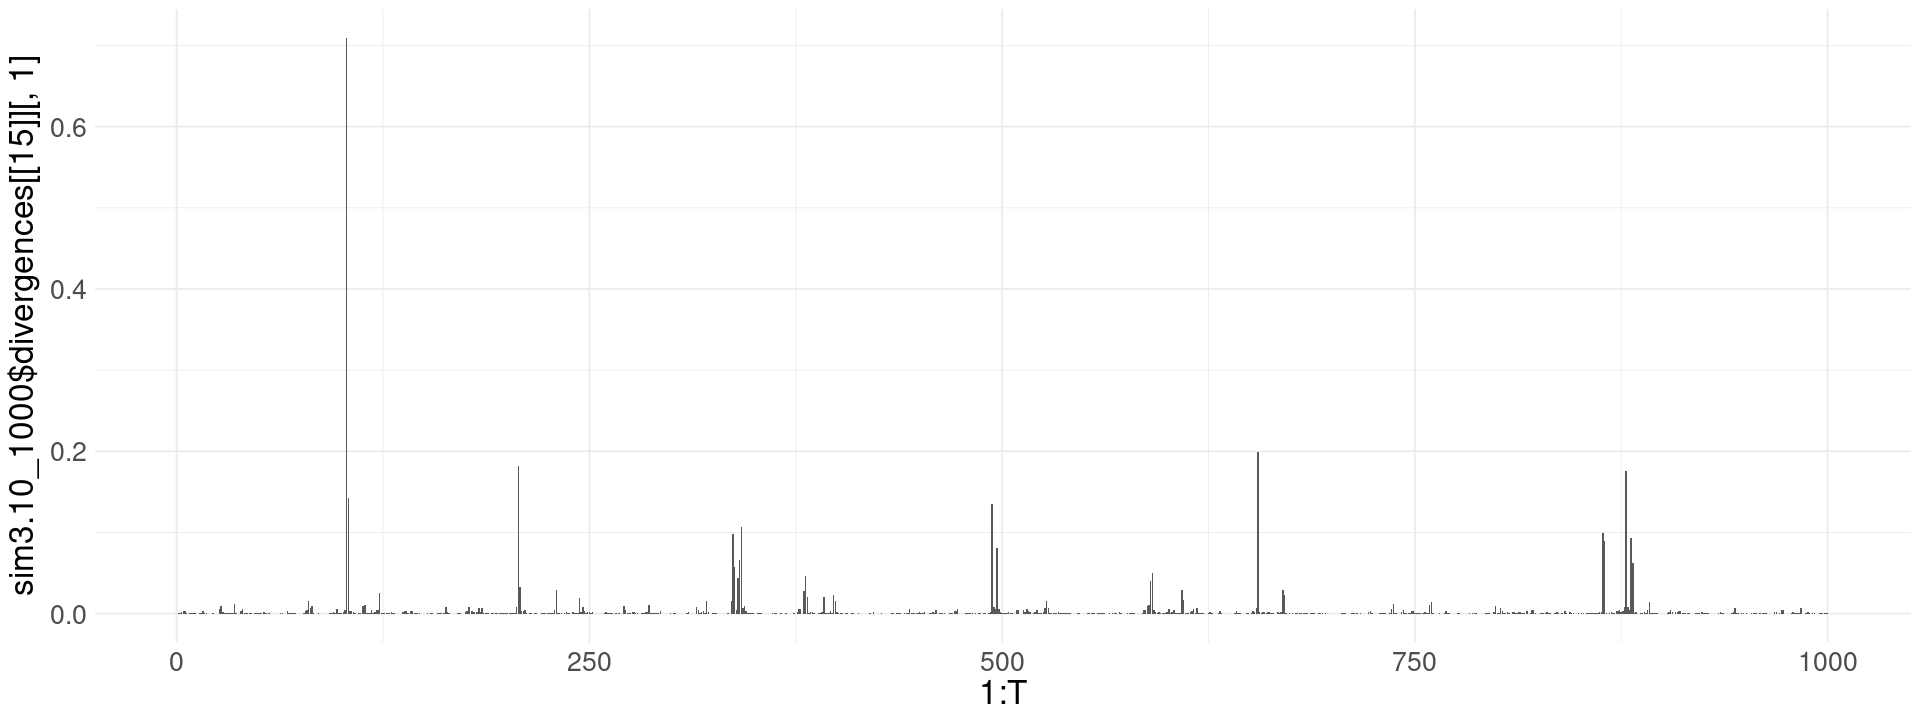

In [83]:
options(repr.plot.width = 16, repr.plot.height = 6)
ggplot()+
    geom_col(aes(x = 1:T, y = sim3.10_1000$divergences[[15]][,1]))

# GARCH(2,1) simulations

In [14]:
garch21_div_sim <- function(nsim, T, alpha, beta, disturbed = NULL, L = 5, niter = 10000, burnin = 5000, seed = 42){
    # -------------------------------- Save the current random state before sampling --------------------------------
    # current_random_state <- .Random.seed
    set.seed(seed)
    
    divergences <- list()
    summaries <- list()
    ys <- list()
    sampling_times <- c()
    divergence_times <- c()
    total_times <- c()
    
    pb <- progressBar(min = 0, max = nsim)
    for(i in 1:nsim){
        # -------------------------------- Sample from the GARCH model --------------------------------
        yh <- sample_garch(T, alpha = alpha, beta = beta)
        y <- yh$y
        h <- yh$h
        
        # -------------------------------- Disturb all indexes required --------------------------------
        for(j in disturbed){
            y[j] <- y[j] + L*sqrt(h[j])*sign(y[j])
        }
        
        # -------------------------------- Fit the Bayesian model --------------------------------
        main_start <- Sys.time()
        # fit_obj <- fit_garch_ardia(y, niter = niter, burnin = burnin, seed = seed+1, emv_guess = c(alpha0, alpha1, beta))
        fit_obj <- sample_posterior_garch_dirichlet_cpp(y, 10000, c(1.0, 0.3, 0.3), c(0.3), 500, 0.05)
        sampling_time <- Sys.time() - start

        # -------------------------------- Process posterior sample --------------------------------
        final_alpha <- fit_obj$alpha[ (burnin+1):niter, ]
        final_beta <- fit_obj$beta[ (burnin+1):niter, ]
        final_hs <- fit_obj$h[(burnin+1):niter,]
        
        summ_colnames <- c("mean", "median", "sd", "2.5%", "25%", "50%", "75%", "97.5%")
        summ_rownames <- c("alpha0", "alpha1", "alpha2", "beta")
        summ <- data.frame(
            c(mean(final_alpha[,1]), mean(final_alpha[,2]), mean(final_alpha[,3]), mean(final_beta)),
            c(median(final_alpha[,1]), median(final_alpha[,2]), median(final_alpha[,3]), median(final_beta)),
            c(sd(final_alpha[,1]), sd(final_alpha[,2]), sd(final_alpha[,3]), sd(final_beta)),
            c(quantile(final_alpha[,1], 0.025), quantile(final_alpha[,2], 0.025), quantile(final_alpha[,3], 0.025), quantile(final_beta, 0.025)),
            c(quantile(final_alpha[,1], 0.25), quantile(final_alpha[,2], 0.25), quantile(final_alpha[,3], 0.25), quantile(final_beta, 0.25)),
            c(quantile(final_alpha[,1], 0.5), quantile(final_alpha[,2], 0.5), quantile(final_alpha[,3], 0.5), quantile(final_beta, 0.5)),
            c(quantile(final_alpha[,1], 0.75), quantile(final_alpha[,2], 0.75), quantile(final_alpha[,3], 0.75), quantile(final_beta, 0.75)),
            c(quantile(final_alpha[,1], 0.975), quantile(final_alpha[,2], 0.975), quantile(final_alpha[,3], 0.975), quantile(final_beta, 0.975))
        )
        colnames(summ) <- summ_colnames
        rownames(summ) <- summ_rownames
        
        # -------------------------------- Extract parameters --------------------------------
        # alpha0, alpha1, beta1
        thetas <- cbind(final_alpha[,1], final_alpha[,2], final_alpha[,3], final_beta)
        
        hs <- final_hs
        colnames(thetas) <- c("alpha0", "alpha1", "alpha2", "beta")
        
        summaries[[i]] <- summ
        
        # -------------------------------- Obtain the divergences --------------------------------
        start <- Sys.time()
        div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 2, q = 1, k_values = 1:T, verbose = FALSE)
        divergence_time <- Sys.time() - start
        
        total_time <- Sys.time() - main_start
        
        # -------------------------------- Save the relevant values --------------------------------
        sampling_times[i] <- sampling_time
        divergence_times[i] <- divergence_time
        total_times[i] <- total_time
        colnames(div) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
        divergences[[i]] <- div
        ys[[i]] <- y
        
        # Invoke the Garbage collector for memory maintenance
        invisible(gc())
        setTxtProgressBar(pb, i)
    }
    close(pb)
    
    # return to the environment to the previous random state
    # .Random.seed <- current_random_state
    
    return(list(
        "ys" = ys,
        "divergences" = divergences,
        "summaries" = summaries,
        "sampling_times" = sampling_times,
        "divergence_times" = divergence_times,
        "total_times" = total_times,
        "pars" = c(alpha, beta)
    ))
}

## Scenario 4 - $\alpha_0 = 1$

* 4.1: $\alpha_1 = 0.05$, $\alpha_2 = 0.05$, $\beta_1 = 0.05$ - Sum: 0.15
* 4.2: $\alpha_1 = 0.05$, $\alpha_2 = 0.05$, $\beta_1 = 0.32$ - Sum: 0.42
* 4.3: $\alpha_1 = 0.05$, $\alpha_2 = 0.05$, $\beta_1 = 0.59$ - Sum: 0.69
* 4.4: $\alpha_1 = 0.05$, $\alpha_2 = 0.05$, $\beta_1 = 0.86$ - Sum: 0.96
* 4.5: $\alpha_1 = 0.05$, $\alpha_2 = 0.32$, $\beta_1 = 0.05$ - Sum: 0.42
* 4.6: $\alpha_1 = 0.05$, $\alpha_2 = 0.32$, $\beta_1 = 0.32$ - Sum: 0.69
* 4.7: $\alpha_1 = 0.05$, $\alpha_2 = 0.32$, $\beta_1 = 0.59$ - Sum: 0.96
* 4.8: $\alpha_1 = 0.05$, $\alpha_2 = 0.59$, $\beta_1 = 0.05$ - Sum: 0.69
* 4.9: $\alpha_1 = 0.05$, $\alpha_2 = 0.59$, $\beta_1 = 0.32$ - Sum: 0.96
* 4.10: $\alpha_1 = 0.05$, $\alpha_2 = 0.86$, $\beta_1 = 0.05$ - Sum: 0.96
* 4.11: $\alpha_1 = 0.32$, $\alpha_2 = 0.05$, $\beta_1 = 0.05$ - Sum: 0.42
* 4.12: $\alpha_1 = 0.32$, $\alpha_2 = 0.05$, $\beta_1 = 0.32$ - Sum: 0.69
* 4.13: $\alpha_1 = 0.32$, $\alpha_2 = 0.05$, $\beta_1 = 0.59$ - Sum: 0.96
* 4.14: $\alpha_1 = 0.32$, $\alpha_2 = 0.32$, $\beta_1 = 0.05$ - Sum: 0.69
* 4.15: $\alpha_1 = 0.32$, $\alpha_2 = 0.32$, $\beta_1 = 0.32$ - Sum: 0.96
* 4.16: $\alpha_1 = 0.32$, $\alpha_2 = 0.59$, $\beta_1 = 0.05$ - Sum: 0.96
* 4.17: $\alpha_1 = 0.59$, $\alpha_2 = 0.05$, $\beta_1 = 0.05$ - Sum: 0.69
* 4.18: $\alpha_1 = 0.59$, $\alpha_2 = 0.05$, $\beta_1 = 0.32$ - Sum: 0.96
* 4.19: $\alpha_1 = 0.59$, $\alpha_2 = 0.32$, $\beta_1 = 0.05$ - Sum: 0.96
* 4.20: $\alpha_1 = 0.86$, $\alpha_2 = 0.05$, $\beta_1 = 0.05$ - Sum: 0.96

### Scenario 4.1 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.05$, $\beta_1 = 0.05$

In [ ]:
sim4.1_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.05), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.1_1000", file = "Simulations2/sim4.1.RData")

### Scenario 4.2 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.05$, $\beta_1 = 0.32$

In [ ]:
sim4.2_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.05), beta = c(0.32), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.2_1000", file = "Simulations2/sim4.2.RData")

### Scenario 4.3 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.05$, $\beta_1 = 0.59$

In [ ]:
sim4.3_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.05), beta = c(0.59), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.3_1000", file = "Simulations2/sim4.3.RData")

### Scenario 4.4 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.05$, $\beta_1 = 0.86$

In [ ]:
sim4.4_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.05), beta = c(0.86), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.4_1000", file = "Simulations2/sim4.4.RData")

### Scenario 4.5 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.32$, $\beta_1 = 0.05$

In [ ]:
sim4.5_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.32), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.5_1000", file = "Simulations2/sim4.5.RData")

### Scenario 4.6 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.32$, $\beta_1 = 0.32$

In [ ]:
sim4.6_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.32), beta = c(0.32), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.6_1000", file = "Simulations2/sim4.6.RData")

### Scenario 4.7 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.32$, $\beta_1 = 0.59$

In [ ]:
sim4.7_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.32), beta = c(0.59), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.7_1000", file = "Simulations2/sim4.7.RData")

### Scenario 4.8 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.59$, $\beta_1 = 0.05$

In [ ]:
sim4.8_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.59), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.8_1000", file = "Simulations2/sim4.8.RData")

### Scenario 4.9 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.59$, $\beta_1 = 0.32$

In [ ]:
sim4.9_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.59), beta = c(0.32), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.9_1000", file = "Simulations2/sim4.9.RData")

### Scenario 4.10 - $\alpha_0 = 1$, $\alpha_1 = 0.05$, $\alpha_2 = 0.86$, $\beta_1 = 0.05$

In [ ]:
sim4.10_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.05, 0.86), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.10_1000", file = "Simulations2/sim4.10.RData")

### Scenario 4.11 - $\alpha_0 = 1$, $\alpha_1 = 0.32$, $\alpha_2 = 0.05$, $\beta_1 = 0.05$

In [ ]:
sim4.11_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.32, 0.05), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.11_1000", file = "Simulations2/sim4.11.RData")

### Scenario 4.12 - $\alpha_0 = 1$, $\alpha_1 = 0.32$, $\alpha_2 = 0.05$, $\beta_1 = 0.32$

In [ ]:
sim4.12_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.32, 0.05), beta = c(0.32), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.12_1000", file = "Simulations2/sim4.12.RData")

### Scenario 4.13 - $\alpha_0 = 1$, $\alpha_1 = 0.32$, $\alpha_2 = 0.05$, $\beta_1 = 0.59$

In [22]:
sim4.13_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.32, 0.05), beta = c(0.59), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.13_1000", file = "Simulations2/sim4.13.RData")

  |=======                                                 |  13%, ETA 02:23:20

### Scenario 4.14 - $\alpha_0 = 1$, $\alpha_1 = 0.32$, $\alpha_2 = 0.32$, $\beta_1 = 0.05$

In [21]:
sim4.14_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.32, 0.32), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.14_1000", file = "Simulations2/sim4.14.RData")

  |====================================================| 100%, Elapsed 02:48:28


### Scenario 4.15 - $\alpha_0 = 1$, $\alpha_1 = 0.32$, $\alpha_2 = 0.32$, $\beta_1 = 0.32$

In [20]:
sim4.15_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.32, 0.32), beta = c(0.32), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.15_1000", file = "Simulations2/sim4.15.RData")

  |====================================================| 100%, Elapsed 02:49:25


### Scenario 4.16 - $\alpha_0 = 1$, $\alpha_1 = 0.32$, $\alpha_2 = 0.59$, $\beta_1 = 0.05$

In [19]:
sim4.16_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.32, 0.59), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.16_1000", file = "Simulations2/sim4.16.RData")

  |====================================================| 100%, Elapsed 02:49:15


### Scenario 4.17 - $\alpha_0 = 1$, $\alpha_1 = 0.59$, $\alpha_2 = 0.05$, $\beta_1 = 0.05$

In [18]:
sim4.17_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.59, 0.05), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.17_1000", file = "Simulations2/sim4.17.RData")

  |====================================================| 100%, Elapsed 02:48:11


### Scenario 4.18 - $\alpha_0 = 1$, $\alpha_1 = 0.59$, $\alpha_2 = 0.05$, $\beta_1 = 0.32$

In [17]:
sim4.18_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.59, 0.05), beta = c(0.32), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.18_1000", file = "Simulations2/sim4.18.RData")

  |====================================================| 100%, Elapsed 02:49:29


### Scenario 4.19 - $\alpha_0 = 1$, $\alpha_1 = 0.59$, $\alpha_2 = 0.32$, $\beta_1 = 0.05$

In [16]:
sim4.19_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.59, 0.32), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.19_1000", file = "Simulations2/sim4.19.RData")

  |====================================================| 100%, Elapsed 02:51:11


### Scenario 4.20 - $\alpha_0 = 1$, $\alpha_1 = 0.86$, $\alpha_2 = 0.05$, $\beta_1 = 0.05$

In [15]:
sim4.20_1000 <- garch21_div_sim(nsim = nsim, T = 1000, alpha = c(1.0, 0.86, 0.05), beta = c(0.05), disturbed = NULL, L = 5,
                               niter = 10000, burnin = 5000, seed = 10)
save("sim4.20_1000", file = "Simulations2/sim4.20.RData")

  |====================================================| 100%, Elapsed 02:48:36
